# 01 · In-Context Linear Regression — Sanity Check

**Headline research question.**
> Along the compute axis from gated linear attention to MesaNet's exact solve, when — and for which task properties — does the added test-time compute outperform Gated DeltaNet's single-step delta rule?

This notebook is the **first, smallest** step toward that RQ: a *sanity check* on clean in-context linear regression. It is **not a finding** — the job is to reproduce, in a minimal controlled setting, the behaviour the papers already imply, and to confirm our harness is correct before we trust anything on harder tasks.

**Pre-registered expectation.** MesaNet performs an *exact* least-squares (RLS-like) solve over its in-context history, so it should reach low query-MSE with **few** in-context examples (≈ the key dimension `d`). Gated DeltaNet applies a *single* gated delta update per token (LMS-like), so it should need **many more** examples for comparable MSE. We expect a visible **RLS-vs-LMS gap**, Mesa sitting to the *left* of GDN on the MSE-vs-examples curve.

If the gap does **not** appear, that is information about our setup — not a refutation of the papers. Hence *sanity check*.

## Experimental design (stated explicitly)

- **Train-across / evaluate-per-setting (default).** We train **one** model per condition across a *distribution* of the difficulty knob (number of in-context examples), then measure held-out MSE **separately at each** number of examples. This matches how the layers are used (one model, many context lengths) and avoids confounding capability with per-length overfitting. The alternative — one model per knob value (`train_eval`) — exists but is not used here.
- **Clean task.** Noiseless `y = Wx` (`noise=0`), stationary `W` (`drift=0`). Noise and drift are deferred to later notebooks.
- **Tiny regime.** 2 layers, small width — runs on a single GPU. (The CG-semantics check below runs on CPU.)
- **Held-out = fresh seeds.** Eval batches come from a disjoint seed range, so the model must generalize to new random `W`/`x`, not memorize.
- **Identical scoring path.** Every metric goes through `synthtasks.metrics.mse_on_queries` — the *same* function the closed-form sanity check uses — so model error and oracle floor are directly comparable.
- **Reproducible.** All runs are seeded.
- **Equalized initialization (important, and disclosed).** fla's stock MesaNet decay gate forgets ~half its state per token at init (`a_proj.bias ~ 0` so initial decay = `exp(logsigmoid(0)) ~ 0.5`), while Gated DeltaNet's Mamba-style init starts at decay ~ 1 (retain everything). For in-context regression — where the *whole* demonstration history must be kept — Mesa's stock prior is wrong, and at a small step budget Mesa burns its training just learning **not to forget**, which superficially looks like “GDN wins.” We therefore seed Mesa's decay-gate bias toward retention (`MESA_RETENTION`, initial decay ~ 1) so both layers start from the same prior; the bias stays fully trainable. Set `MESA_RETENTION = None` to reproduce the stock-init behaviour (GDN appears dominant until ~5× more steps) — a budget/initialization artifact, not an RLS-vs-LMS finding.

> **Environment note.** `MesaNet`/`GatedDeltaNet` are `flash-linear-attention` layers that require **CUDA + Triton**; run this notebook on a GPU box. Only the CG-semantics verification (Step 1) runs on CPU.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `compare` and `synthtasks` importable

import numpy as np
import torch
import matplotlib.pyplot as plt

from compare.experiments import (
    SweepConfig, verify_cg_semantics, check_lambda_collapse,
    regression_examples_sweep, mesa_cg_sweep, mesa_lambda_sweep, oracle_mse_curve,
)
from compare.profile import compute_profile   # FLOPs / throughput / latency / memory (Step 3)

# ----- easily-edited config (shrink `steps` for a quick smoke run) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16 if DEVICE == "cuda" else torch.float32   # fla chunk kernels prefer bf16 on CUDA

D             = 8                                  # regression key dimension
EVAL_EXAMPLES = [4, 8, 12, 16, 24, 32, 48, 64]     # in-context example counts to evaluate at
CG_GRID       = [1, 2, 5, 10, 30]                  # Mesa CG steps (k=0 is a degenerate floor; see Step 1)
LAMBDA_GRID   = [0.25, 1, 4, 16, 50, 200]          # Mesa ridge regularizer Λ (see Step 1b)
MESA_RETENTION = 4.0                               # Mesa decay-gate bias init (fairness; see design note). None = stock fla
SEED          = 0

cfg = SweepConfig(
    d=D, noise=0.0,
    batch_size=64, steps=600,        # bump `steps` for cleaner curves; lower for a quick smoke run
    hidden_size=128, num_heads=4, num_layers=2,
    eval_batches=4,
    mesa_retention_init=MESA_RETENTION,
    dtype=DTYPE, device=DEVICE,
)
print(f"device={DEVICE}  dtype={DTYPE}  steps={cfg.steps}  mesa_retention_init={cfg.mesa_retention_init}")

device=cuda  dtype=torch.bfloat16  steps=600  mesa_retention_init=4.0


## Step 1 — Free correctness check: what does the CG-step count actually compute?

Before comparing anything, we verify Mesa's **CG dial** against the *installed* kernel rather than our memory of the paper. MesaNet solves `(KᵀK + λI) x = q` for the read-out weights by conjugate gradient; the number of CG steps `k` is the compute dial.

A common claim is *"k=0 reduces to gated linear attention (GLA)."* **We checked the installed `fla-core` kernel and that is not what happens here:** the CG solver **cold-starts at `x=0`**, so

- **`k=0` → mixer output is exactly zero** (no token mixing at all) — a degenerate floor, *not* GLA;
- **`k=1` → the GLA read-out up to a per-token scalar** — the true GLA-equivalent point;
- **`k→large` → the exact least-squares solve.**

Consequence for this notebook: the GLA end of the sweep is **`k=1`**, and we **exclude the degenerate `k=0`** from the plots. The check below uses fla's pure-torch reference (no Triton, runs on CPU) and must PASS before we trust the comparison.

In [2]:
sem = verify_cg_semantics(seed=SEED)
print("CG-semantics check (installed fla kernel, pure-torch CPU reference):")
print(f"  ||o(CG=0)||                  = {sem.cg0_output_norm:.2e}   "
      f"-> {'PASS' if sem.pass_cg0_is_zero else 'FAIL'}: CG=0 is zero (NOT GLA)")
print(f"  CG=1 vs GLA parallelism      = {sem.cg1_vs_gla_parallelism:.2e}   "
      f"-> {'PASS' if sem.pass_cg1_is_gla else 'FAIL'}: CG=1 == GLA up to a scalar")
print(f"  ||o(CG=30)-o_exact||/||..||  = {sem.cg30_rel_error:.2e}   "
      f"-> {'PASS' if sem.pass_converges_to_exact else 'FAIL'}: converges to exact solve")
print(f"\noverall: {'PASS' if sem.all_pass else 'FAIL'}")
assert sem.all_pass, "CG semantics check failed — do not interpret the comparison below."

/home/vzer/Documents/phd/linear_rnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CG-semantics check (installed fla kernel, pure-torch CPU reference):
  ||o(CG=0)||                  = 0.00e+00   -> PASS: CG=0 is zero (NOT GLA)
  CG=1 vs GLA parallelism      = 4.42e-07   -> PASS: CG=1 == GLA up to a scalar
  ||o(CG=30)-o_exact||/||..||  = 1.32e-04   -> PASS: converges to exact solve

overall: PASS


## Step 1b — The regularizer Λ: a second collapse path, and what it costs

The CG-step count is one dial onto the GLA reference; the **regularizer Λ is a second, independent one**. Mesa solves `x_t = (H_t + Λ)⁻¹ q_t` and reads out a form *linear in* `x_t`. Under a **large fixed Λ** (the paper's magnitude, `Λ ≈ 50·I`), `(H_t + Λ)⁻¹ ≈ Λ⁻¹` — the accumulated key-correlation state `H_t` drops out — so `x_t ≈ q_t/λ` and, by linearity, the read-out collapses onto the **same GLA anchor** the CG check uses, up to a constant rescale `α ≈ 1/λ`. That two *independent* controls (CG→1 and Λ→large) both land on the **same** GLA reference is a strong correctness signal — the GLA endpoint is not an artifact of one code path. The check below confirms the collapse at `Λ=50` on CPU (cosine + rescaled query-MSE through `mse_on_queries`), and must PASS.

**The figure makes the performance consequence explicit.** Collapsing toward GLA isn't free: it throws away the in-context history `H_t` the exact solve relies on. So we pin Mesa's ridge `Λ` at a grid of values (CG held at 30) and plot **held-out query MSE vs Λ**, with the trained Gated DeltaNet as the reference. Reading it: MSE **rises monotonically with Λ** — stronger regularization degrades MesaNet — and **crosses the GDN line**, so Mesa sits *below* GDN (its extra compute pays off) only at **small Λ**; by the paper's `Λ=50` it has degraded *past* GDN. This is the regularization-strength counterpart to the CG-step sweep in Step 2.

Λ-collapse check (Mesa Λ=50·I vs the same GLA anchor, up to rescale α):
  cosine(o_Λ, o_gla)   = 0.999958   -> PASS: collapses to the GLA direction
  rescaled query-MSE   = 2.54e-08  (rel 8.45e-05)   -> PASS: residual << signal   [α≈1/Λ=0.0195]
  overall: PASS
Mesa Λ=0.25  mean MSE = 0.422
Mesa Λ=1     mean MSE = 0.445
Mesa Λ=4     mean MSE = 0.492
Mesa Λ=16    mean MSE = 0.532
Mesa Λ=50    mean MSE = 0.545
Mesa Λ=200   mean MSE = 0.551
Gated DeltaNet  mean MSE = 0.492


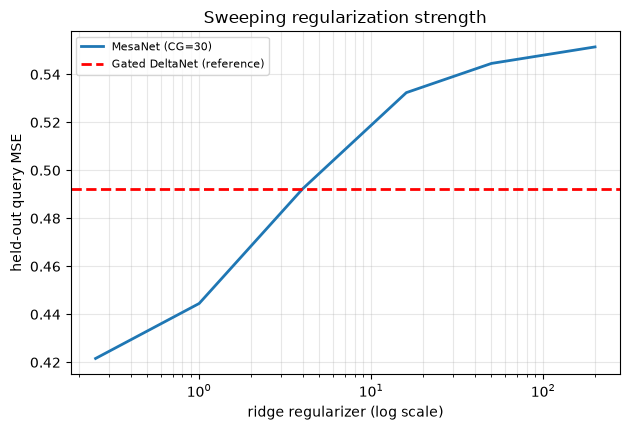

In [ ]:
# --- correctness gate (CPU, fast): large Λ collapses Mesa onto the GLA anchor ---
lam = check_lambda_collapse(seed=SEED)   # paper magnitude Λ = 50·I
print(f"Λ-collapse check (Mesa Λ={lam.lambda_value:.0f}·I vs the same GLA anchor, up to rescale α):")
print(f"  cosine(o_Λ, o_gla)   = {lam.cosine:.6f}   "
      f"-> {'PASS' if lam.pass_directional else 'FAIL'}: collapses to the GLA direction")
print(f"  rescaled query-MSE   = {lam.query_mse:.2e}  (rel {lam.rel_mse:.2e})   "
      f"-> {'PASS' if lam.pass_rescaled else 'FAIL'}: residual << signal   [α≈1/Λ={lam.alpha:.4f}]")
print(f"  overall: {'PASS' if lam.all_pass else 'FAIL'}")
assert lam.all_pass, "Λ-collapse check failed — large-Λ degeneration to GLA does not hold."

# --- performance consequence: held-out MSE as the regularizer Λ grows (trains on GPU) ---
# Pin Mesa's ridge Λ at each value (CG fixed at 30) and measure held-out MSE; GDN is the
# reference. Stronger Λ over-regularizes the in-context solve, so MSE should climb and
# cross the GDN line — Mesa's exact-solve edge only survives at *small* Λ.
lam_sweep = mesa_lambda_sweep(
    lambda_grid=LAMBDA_GRID, eval_examples=EVAL_EXAMPLES,
    train_examples=EVAL_EXAMPLES, mesa_cg=30, seed=SEED, cfg=cfg,
)
lams     = np.array(LAMBDA_GRID, dtype=float)
mesa_mse = np.array([np.mean(lam_sweep["per_lambda"][L]["metric"]) for L in LAMBDA_GRID])
gdn_mse  = float(np.mean(lam_sweep["gdn"]["metric"]))
for L, m in zip(LAMBDA_GRID, mesa_mse):
    print(f"Mesa Λ={L:<5} mean MSE = {m:.3f}")
print(f"Gated DeltaNet  mean MSE = {gdn_mse:.3f}")




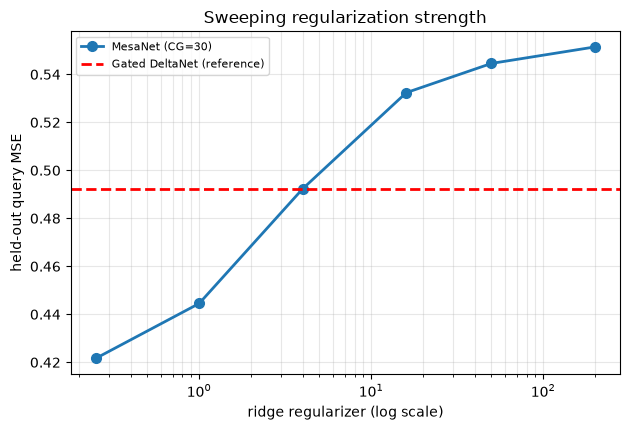

In [18]:
plt.figure(figsize=(6.4, 4.4))
plt.semilogx(lams, mesa_mse, "o-", color="C0", lw=2, ms=7, label="MesaNet (CG=30)")
plt.axhline(gdn_mse, color="r", ls="--", lw=2, label="Gated DeltaNet (reference)")
# plt.fill_between(lams, mesa_mse, gdn_mse, where=(mesa_mse <= gdn_mse),
#                  color="C2", alpha=0.18, label="Mesa below GDN (compute worth it)")
j50 = LAMBDA_GRID.index(50)
# plt.scatter([lams[j50]], [mesa_mse[j50]], s=170, marker="*", color="C3", zorder=5,
#             label="Λ=50 (paper magnitude)")
plt.xlabel("ridge regularizer (log scale)")
plt.ylabel("held-out query MSE")
plt.title("Sweeping regularization strength")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.savefig("figures/regression_3.png", dpi=600)
plt.tight_layout()
plt.show()

## Step 2 — Mesa CG-step sweep: from GLA-like toward exact

Now hold the task fixed and sweep Mesa's compute dial `k ∈ {1, 2, 5, 10, 30}`. Per Step 1, **`k=1` is the GLA-equivalent point** (cheapest) and larger `k` approaches the **exact** solve. Gated DeltaNet is drawn as a **reference** — the practical incumbent we're asking whether the extra Mesa compute is worth beating. The Mesa `k=30` curve (exact solve) and the GDN reference together are the headline MesaNet-vs-GatedDeltaNet comparison.

*Expectation:* curves descend as `k` grows (more compute → lower MSE at fewer examples), with diminishing returns; the `k=1` curve is the weakest.

> *Honesty note:* GDN's error also depends on context length, so we plot its **full curve** as the reference rather than a single horizontal line.

In [4]:
cg_results = mesa_cg_sweep(
    cg_grid=CG_GRID, eval_examples=EVAL_EXAMPLES,
    train_examples=EVAL_EXAMPLES, with_gdn_reference=True, seed=SEED, cfg=cfg,
)
for k in cg_results["cg_grid"]:
    print(f"Mesa CG={k:<2d} MSE = {[round(m, 3) for m in cg_results['per_cg'][k]['metric']]}")

Mesa CG=1  MSE = [0.92, 0.795, 0.672, 0.555, 0.515, 0.455, 0.366, 0.342]
Mesa CG=2  MSE = [0.881, 0.748, 0.57, 0.45, 0.393, 0.329, 0.24, 0.213]
Mesa CG=5  MSE = [0.869, 0.717, 0.55, 0.429, 0.354, 0.279, 0.193, 0.167]
Mesa CG=10 MSE = [0.861, 0.721, 0.544, 0.421, 0.348, 0.276, 0.192, 0.164]
Mesa CG=30 MSE = [0.862, 0.713, 0.54, 0.415, 0.343, 0.273, 0.182, 0.153]


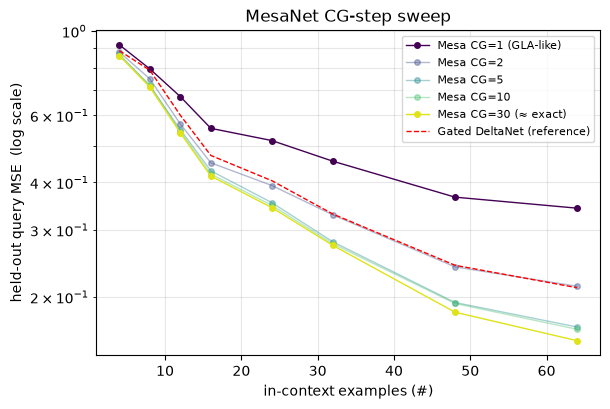

In [14]:
plt.figure(figsize=(6.2, 4.2))
cg_grid = cg_results["cg_grid"]
colors = plt.cm.viridis(np.linspace(0, .95, len(cg_grid)))
for color, k in zip(colors, cg_grid):
    r = cg_results["per_cg"][k]
    tag = " (GLA-like)" if k == 1 else (" (≈ exact)" if k == 30 else "")
    is_outer = k in (cg_grid[0], cg_grid[-1])          # keep the two end curves bold,
    alpha = 1.0 if is_outer else 0.4                    # fade the in-between ones
    plt.plot(r["eval_knobs"], r["metric"], color=color,
             alpha=alpha, label=f"Mesa CG={k}{tag}", marker="o", markersize=4, lw=1)
gdn = cg_results["gdn"]
plt.plot(gdn["eval_knobs"], gdn["metric"], "r--", lw=1, label="Gated DeltaNet (reference)")
plt.yscale("log")
plt.xlabel("in-context examples (#)")
plt.ylabel("held-out query MSE  (log scale)")
plt.title("MesaNet CG-step sweep")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/regression_2.png", dpi=600)
plt.show()

**Reading it.** More CG steps = more test-time compute = closer to the exact RLS solve, so curves should descend with `k` and saturate by `k ≈ 10`. The gap between `k=1` (GLA-like) and `k=30` (exact) is the *value of the extra compute*; the gap between the Mesa curves and the GDN reference is the headline trade-off this project measures.